### Project Overview

This project analyzes the sales, expenses, profitability, and performance of Rice and Beans across January, February, and March.

The analysis uses Python, Pandas, and Matplotlib to clean the data, calculate key financial metrics, identify trends, visualize business performance, and develop evidence-based recommendations.

### Key Questions

- Which product generated the highest sales?
- Which product generated the highest profit?
- How did profit change over the three-month period?
- How did sales compare with expenses?
- Which month recorded the highest profit margin?
- What expense patterns require further investigation?

# Sales & Profitability Analysis — Rice & Beans

**Objective:** Analyze sales, expenses, profitability, and business performance across January, February, and March.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame({
      "Product": ["Rice", "Beans", "Rice", "Beans", "Rice", "Beans"],
          "Month": ["January", "January", "February", "February", "March", "March"],
              "Sales": [400000, 250000, 550000, 300000, 600000, 350000],
                  "Expenses": [250000, 150000, 300000, 180000, 350000, 200000]
                  })

df

,Product,Month,Sales,Expenses
0,Rice,January,400000,250000
1,Beans,January,250000,150000
2,Rice,February,550000,300000
3,Beans,February,300000,180000
4,Rice,March,600000,350000
5,Beans,March,350000,200000


In [ ]:
df.head()

,Product,Month,Sales,Expenses
0,Rice,January,400000,250000
1,Beans,January,250000,150000
2,Rice,February,550000,300000
3,Beans,February,300000,180000
4,Rice,March,600000,350000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product        6 non-null      object 
 1   Month          6 non-null      object 
 2   Sales          6 non-null      int64  
 3   Expenses       6 non-null      int64  
 4   Profit         6 non-null      int64  
 5   Profit_Margin  6 non-null      float64
 6   Expense_Ratio  6 non-null      float64
dtypes: float64(2), int64(3), object(2)
memory usage: 468.0+ bytes


In [ ]:
df.describe()

,Sales,Expenses
count,6.000000,6.000000
mean,408333.333333,238333.333333
std,139343.699774,76267.074591
min,250000.000000,150000.000000
25%,312500.000000,185000.000000
50%,375000.000000,225000.000000
75%,512500.000000,287500.000000
max,600000.000000,350000.000000


In [ ]:
df.isnull().sum()

,0
Product,0
Month,0
Sales,0
Expenses,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Profit"] = df["Sales"] - df["Expenses"]

df

,Product,Month,Sales,Expenses,Profit
0,Rice,January,400000,250000,150000
1,Beans,January,250000,150000,100000
2,Rice,February,550000,300000,250000
3,Beans,February,300000,180000,120000
4,Rice,March,600000,350000,250000
5,Beans,March,350000,200000,150000


In [ ]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

df

,Product,Month,Sales,Expenses,Profit,Profit_Margin
0,Rice,January,400000,250000,150000,37.500000
1,Beans,January,250000,150000,100000,40.000000
2,Rice,February,550000,300000,250000,45.454545
3,Beans,February,300000,180000,120000,40.000000
4,Rice,March,600000,350000,250000,41.666667
5,Beans,March,350000,200000,150000,42.857143


In [ ]:
df["Expense_Ratio"] = (df["Expenses"] / df["Sales"]) * 100

df

,Product,Month,Sales,Expenses,Profit,Profit_Margin,Expense_Ratio
0,Rice,January,400000,250000,150000,37.500000,62.500000
1,Beans,January,250000,150000,100000,40.000000,60.000000
2,Rice,February,550000,300000,250000,45.454545,54.545455
3,Beans,February,300000,180000,120000,40.000000,60.000000
4,Rice,March,600000,350000,250000,41.666667,58.333333
5,Beans,March,350000,200000,150000,42.857143,57.142857


In [ ]:
product_sales = df.groupby("Product")["Sales"].sum()

product_sales

,Sales
Product,
Beans,900000
Rice,1550000


In [ ]:
product_profit = df.groupby("Product")["Profit"].sum()

product_profit

,Profit
Product,
Beans,370000
Rice,650000


In [ ]:
monthly_profit = df.groupby("Month")["Profit"].sum()

monthly_profit

,Profit
Month,
February,370000
January,250000
March,400000


In [ ]:
monthly_profit = (
      df.groupby("Month")["Profit"]
          .sum()
              .reindex(["January", "February", "March"])


)

monthly_profit

,Profit
Month,
January,250000
February,370000
March,400000


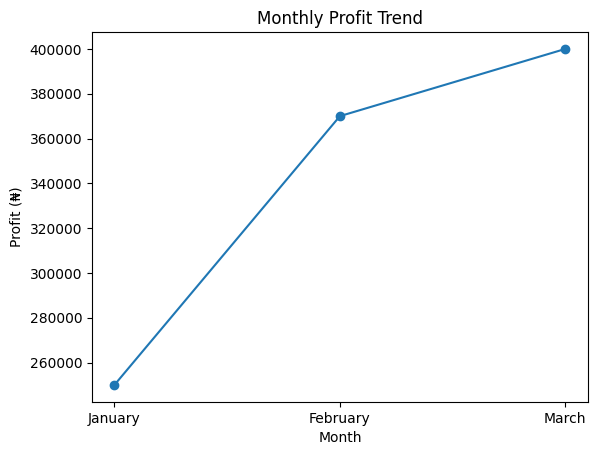

In [ ]:
plt.plot(monthly_profit.index, monthly_profit.values, marker="o")

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit (₦)")

plt.show()

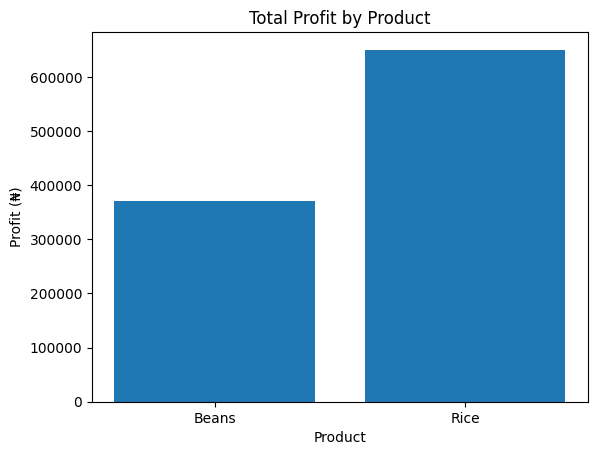

In [ ]:
plt.bar(product_profit.index, product_profit.values)

plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Profit (₦)")

plt.show()

In [ ]:
monthly = df.groupby("Month")[["Sales", "Expenses", "Profit"]].sum()

monthly = monthly.reindex(["January", "February", "March"])

monthly

,Sales,Expenses,Profit
Month,,,
January,650000,400000,250000
February,850000,480000,370000
March,950000,550000,400000


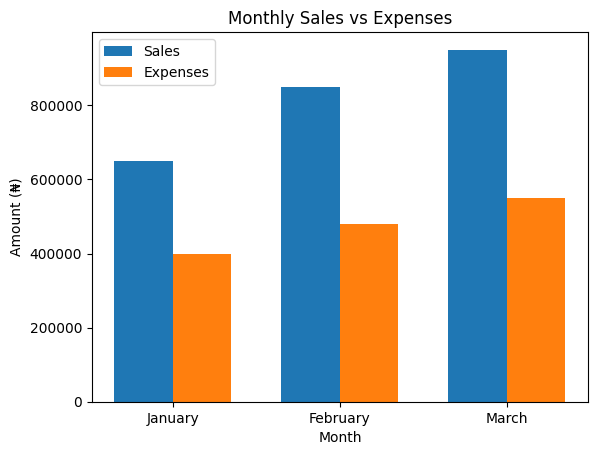

In [ ]:
import numpy as np

x = np.arange(len(monthly.index))
width = 0.35

plt.bar(x - width/2, monthly["Sales"], width, label="Sales")
plt.bar(x + width/2, monthly["Expenses"], width, label="Expenses")

plt.title("Monthly Sales vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount (₦)")
plt.xticks(x, monthly.index)
plt.legend()

plt.show()

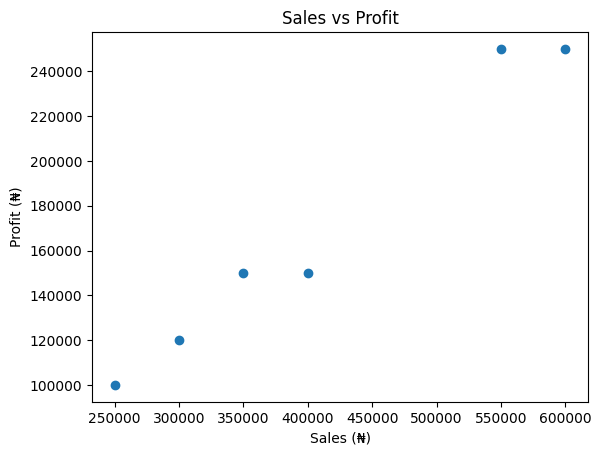

In [ ]:
plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales (₦)")
plt.ylabel("Profit (₦)")

plt.show()

In [ ]:
avg_expense_ratio = df.groupby("Product")["Expense_Ratio"].mean()

avg_expense_ratio

,Expense_Ratio
Product,
Beans,59.047619
Rice,58.459596


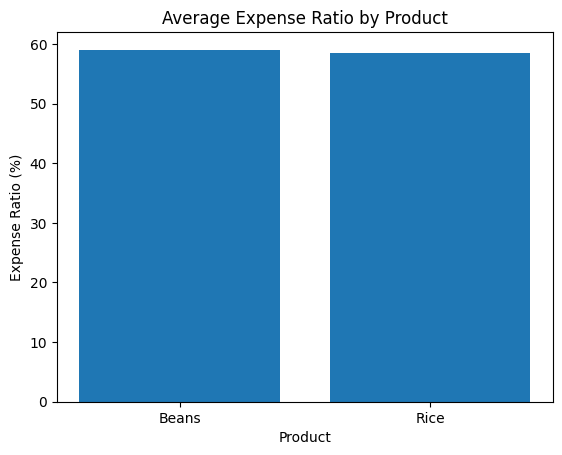

In [ ]:
plt.bar(avg_expense_ratio.index, avg_expense_ratio.values)

plt.title("Average Expense Ratio by Product")
plt.xlabel("Product")
plt.ylabel("Expense Ratio (%)")

plt.show()

In [ ]:
total_sales = df["Sales"].sum()
total_expenses = df["Expenses"].sum()
total_profit = df["Profit"].sum()

print("Total Sales: ₦", total_sales)
print("Total Expenses: ₦", total_expenses)
print("Total Profit: ₦", total_profit)

Total Sales: ₦ 2450000
Total Expenses: ₦ 1430000
Total Profit: ₦ 1020000


In [ ]:
overall_profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", overall_profit_margin, "%")

Overall Profit Margin: 41.63265306122449 %


In [ ]:
monthly["Profit_Margin"] = (monthly["Profit"] / monthly["Sales"]) * 100

monthly

,Sales,Expenses,Profit,Profit_Margin
Month,,,,
January,650000,400000,250000,38.461538
February,850000,480000,370000,43.529412
March,950000,550000,400000,42.105263


## Business Insights

1. Overall Performance
The business generated ₦2,450,000 in total sales, ₦1,430,000 in total expenses, and ₦1,020,000 in total profit, resulting in an overall profit margin of approximately 41.63%.

2. Product Performance
Rice generated the highest total sales at ₦1,550,000 and the highest total profit at ₦650,000, compared with ₦900,000 in sales and ₦370,000 in profit for Beans.

3. Monthly Performance
Profit increased consistently from ₦250,000 in January to ₦370,000 in February and ₦400,000 in March. March recorded the highest monthly sales and total profit.

4. Profitability
February recorded the highest monthly profit margin at approximately 43.53%, despite March having higher sales and total profit.

5. Expense Pattern
Average expense ratios were approximately 59.05% for Beans and 58.46% for Rice. The difference is small, so it does not by itself indicate a major cost problem with either product.

6. Sales and Profit Relationship.
The scatter plot shows a positive relationship between sales and profit within this six-record dataset. However, the small dataset means this relationship should be interpreted cautiously rather than treated as a general business rule.

## Business Recommendations

1. Monitor Profitable Sales:
Management should continue monitoring sales activities and products that generate strong profits, rather than focusing on sales volume alone.

2. Investigate Expense Patterns:
Management should review production, distribution, inventory, and other operating costs to identify avoidable expenses and opportunities for cost control.

3. Protect the Positive Sales Trend:
Since sales and profit increased throughout the three-month period, management should maintain strategies associated with the observed growth while monitoring whether additional sales continue to generate sufficient profit.
4. Review Beans Expense Ratio:
Beans recorded a slightly higher average expense ratio than Rice. Management should investigate the underlying cost components to determine whether any avoidable expenses can be reduced without affecting product quality or sales.

5. Use More Detailed Expense Data:
Future analysis should include detailed expense categories such as production, transportation, inventory, marketing, and other operating costs. This would make it easier to identify the specific sources of high expenses.

6. Continue Monitoring Profit Margins:
Management should monitor profit margins alongside total sales and profit, since the month with the highest sales does not necessarily have the highest profit margin.

## Limitations

1. The dataset contains only six records covering three months, so the findings should not be generalized to longer periods without additional data.

2. The expense data is not broken down into categories such as production, transportation, inventory, marketing, or other operating costs. Therefore, the analysis cannot identify the specific causes of high expenses.

3. The dataset contains only two products, Rice and Beans, so the findings may not represent the performance of a wider product range.

4. The analysis identifies relationships and patterns within the available data, but it does not establish causation.

5. More historical data would be required to determine whether the observed sales and profit trends are sustained over time.

#Conclusion


This analysis examined the sales, expenses, and profitability of Rice and Beans across January, February, and March. Overall, Rice generated the highest total sales and profit, contributing ₦650,000 in total profit, while March recorded the highest monthly sales and total profit. Profit also increased consistently throughout the three-month period, rising from ₦250,000 in January to ₦400,000 in March.

The findings suggest that management should focus on profitable sales rather than sales volume alone, while continuously monitoring expense patterns and profitability trends. In particular, management should investigate opportunities to reduce unnecessary costs without negatively affecting sales or product quality. Further analysis using more detailed expense data would help identify the specific cost areas requiring attention.

Because the dataset contains only six records covering three months, these findings should be treated as directional rather than definitive. Additional historical and more detailed business data would provide a stronger basis for future analysis and decision-making.